# Question 2

Due to some unknown security error on my laptop I had to run it on Kaggle Notebook.

## Part B

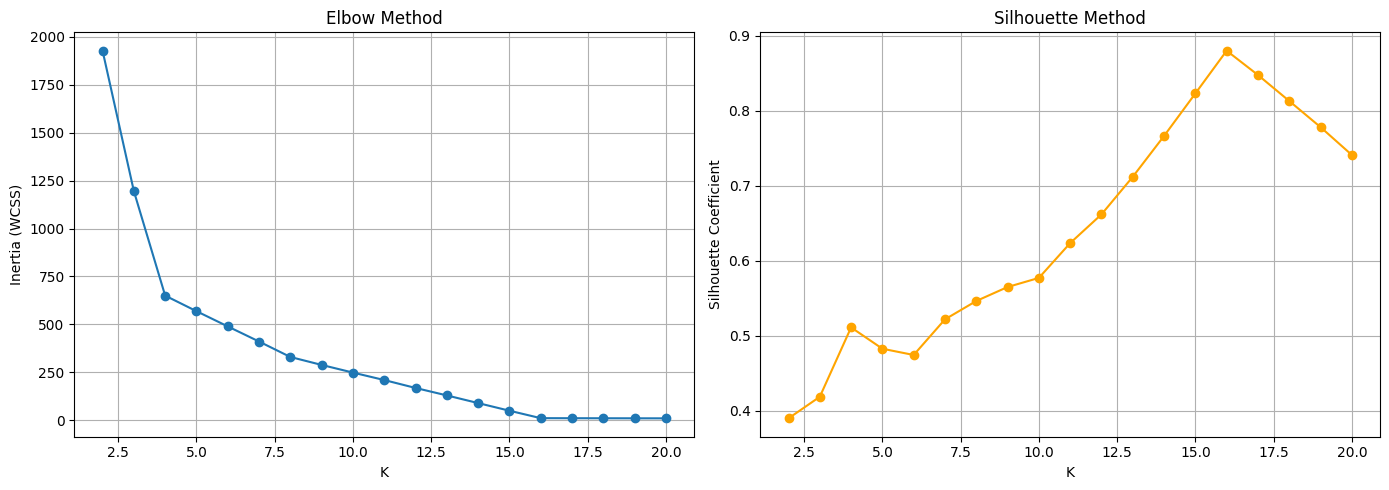

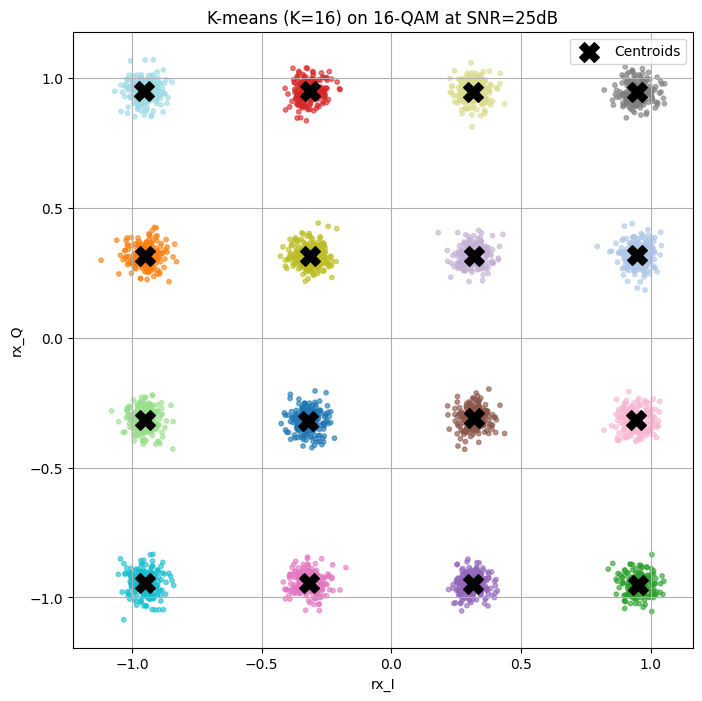

Purity - Feature Set 1 (Cartesian):        1.0000
Purity - Feature Set 2 (Polar):             1.0000
Purity - Feature Set 3 (All 4, scaled):     1.0000


In [1]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# please update the CSV data path to where you have kept it or stored it. as this is code ran in kaggle I had this path.
df = pd.read_csv('/kaggle/input/datasets/dhavala579/com-837-ml-for-wireless-communication/qam16_dataset_with_features.csv')

# Isolate SNR = 25 dB subset — everything in Part (b) uses only this slice
subset_25 = df[df['snr_db'] == 25].reset_index(drop=True)

X_cartesian = subset_25[['rx_I', 'rx_Q']].values

k_values = range(2, 21)
inertia_list = []
silhouette_list = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_cartesian)

    inertia_list.append(kmeans.inertia_)
    sil_score = silhouette_score(X_cartesian, labels)
    silhouette_list.append(sil_score)

# Plot both side by side
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(list(k_values), inertia_list, marker='o')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia (WCSS)'); axes[0].set_title('Elbow Method')
axes[0].grid(True)

axes[1].plot(list(k_values), silhouette_list, marker='o', color='orange')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Coefficient'); axes[1].set_title('Silhouette Method')
axes[1].grid(True)
plt.tight_layout()
plt.savefig('/kaggle/working/Q2b_elbow_silhouette.png')
plt.show()

kmeans_16 = KMeans(n_clusters=16, init='k-means++', n_init=10, random_state=42)
cluster_labels_16 = kmeans_16.fit_predict(X_cartesian)
centroids_16 = kmeans_16.cluster_centers_   # shape (16, 2)

plt.figure(figsize=(8,8))
plt.scatter(X_cartesian[:,0], X_cartesian[:,1], c=cluster_labels_16, cmap='tab20', s=10, alpha=0.6)
plt.scatter(centroids_16[:,0], centroids_16[:,1], c='black', marker='X', s=200, label='Centroids')
plt.xlabel('rx_I'); plt.ylabel('rx_Q')
plt.title('K-means (K=16) on 16-QAM at SNR=25dB')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.savefig('/kaggle/working/Q2b_kmeans16_scatter.png')
plt.show()

# This function takes array of predicted cluster indices (from KMeans) -> clustered labels and array of ground truth symbol_id values -> true_labels, same length and returns purity score (float, 0 to 1)
def cluster_purity(cluster_labels, true_labels):
    df_temp = pd.DataFrame({'cluster': cluster_labels, 'true_label': true_labels})
    majority_label_per_cluster = df_temp.groupby('cluster')['true_label'].agg(
        lambda x: x.mode().iloc[0]
    )

    predicted_via_majority = df_temp['cluster'].map(majority_label_per_cluster)
    correct = predicted_via_majority == df_temp['true_label']

    purity = correct.mean()
    return purity


true_labels = subset_25['symbol_id'].values

purity_set1 = cluster_purity(cluster_labels_16, true_labels)

X_polar = subset_25[['r', 'theta']].values

kmeans_polar = KMeans(n_clusters=16, init='k-means++', n_init=10, random_state=42)
cluster_labels_polar = kmeans_polar.fit_predict(X_polar)
purity_set2 = cluster_purity(cluster_labels_polar, true_labels)

X_all = subset_25[['rx_I', 'rx_Q', 'r', 'theta']].values

scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)
kmeans_all = KMeans(n_clusters=16, init='k-means++', n_init=10, random_state=42)
cluster_labels_all = kmeans_all.fit_predict(X_all_scaled)
purity_set3 = cluster_purity(cluster_labels_all, true_labels)

print(f"Purity - Feature Set 1 (Cartesian):        {purity_set1:.4f}")
print(f"Purity - Feature Set 2 (Polar):             {purity_set2:.4f}")
print(f"Purity - Feature Set 3 (All 4, scaled):     {purity_set3:.4f}")

## Part c

[Adaptive] SNR=0 dB -> purity=0.2537
[Adaptive] SNR=5 dB -> purity=0.4184
[Adaptive] SNR=10 dB -> purity=0.7653
[Adaptive] SNR=15 dB -> purity=0.9809
[Adaptive] SNR=20 dB -> purity=0.9997
[Adaptive] SNR=25 dB -> purity=1.0000
[Adaptive] SNR=30 dB -> purity=1.0000
[Fixed]    SNR=0 dB -> purity=0.2781
[Fixed]    SNR=5 dB -> purity=0.4709
[Fixed]    SNR=10 dB -> purity=0.7781
[Fixed]    SNR=15 dB -> purity=0.9822
[Fixed]    SNR=20 dB -> purity=0.9997
[Fixed]    SNR=25 dB -> purity=1.0000
[Fixed]    SNR=30 dB -> purity=1.0000


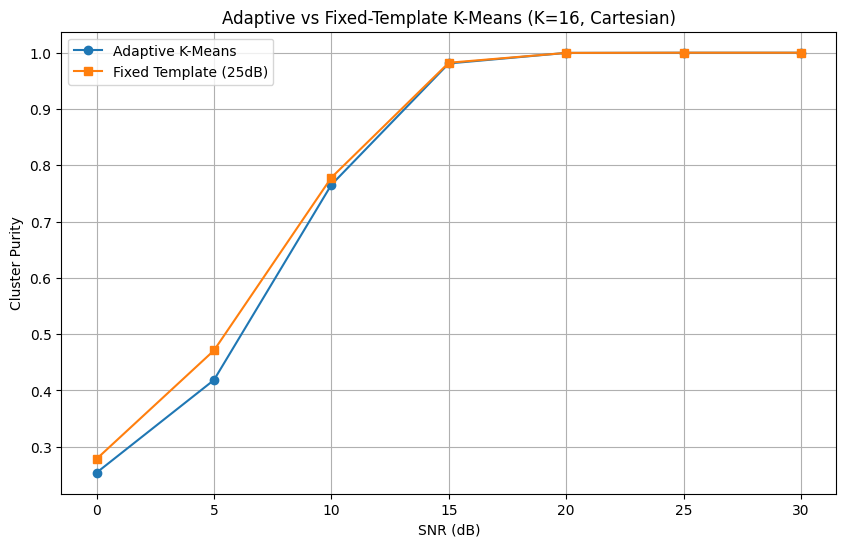

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv('/kaggle/input/datasets/dhavala579/com-837-ml-for-wireless-communication/qam16_dataset_with_features.csv')
snr_values = sorted(df['snr_db'].unique())

def cluster_purity(cluster_labels, true_labels):
    df_temp = pd.DataFrame({'cluster': cluster_labels, 'true_label': true_labels})
    majority = df_temp.groupby('cluster')['true_label'].agg(lambda x: x.mode().iloc[0])
    pred = df_temp['cluster'].map(majority)
    return (pred == df_temp['true_label']).mean()


adaptive_purity = []

for snr_val in snr_values:
    subset = df[df['snr_db'] == snr_val]
    X = subset[['rx_I', 'rx_Q']].values
    true_labels = subset['symbol_id'].values

    # TODO 1: fit a FRESH KMeans (K=16, init='k-means++', n_init=10, random_state=42)
    #         and get its cluster labels in one step
    kmeans = KMeans(n_clusters=16, init='k-means++', n_init=10, random_state=42)
    labels = kmeans.fit_predict(X)

    purity = cluster_purity(labels, true_labels)
    adaptive_purity.append(purity)
    print(f"[Adaptive] SNR={snr_val} dB -> purity={purity:.4f}")


subset_25 = df[df['snr_db'] == 25]
X_25 = subset_25[['rx_I', 'rx_Q']].values


kmeans_fixed = KMeans(n_clusters=16, init='k-means++', n_init=10, random_state=42)


kmeans_fixed.fit(X_25)

fixed_purity = []

for snr_val in snr_values:
    subset = df[df['snr_db'] == snr_val]
    X = subset[['rx_I', 'rx_Q']].values
    true_labels = subset['symbol_id'].values

    labels = kmeans_fixed.predict(X)

    purity = cluster_purity(labels, true_labels)
    fixed_purity.append(purity)
    print(f"[Fixed]    SNR={snr_val} dB -> purity={purity:.4f}")


# Plot
plt.figure(figsize=(10,6))
plt.plot(snr_values, adaptive_purity, marker='o', label='Adaptive K-Means')
plt.plot(snr_values, fixed_purity, marker='s', label='Fixed Template (25dB)')
plt.xlabel('SNR (dB)')
plt.ylabel('Cluster Purity')
plt.title('Adaptive vs Fixed-Template K-Means (K=16, Cartesian)')
plt.legend()
plt.grid(True)
plt.savefig('/kaggle/working/Q2c_adaptive_vs_fixed.png')
plt.show()